<a href="https://colab.research.google.com/github/zehra44/Project/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
df = pd.read_csv("/content/sentiment_analysis_dataset.csv")

In [ ]:
df.head()

,text,sentiment
0,I absolutely loved this product,positive
1,I hated this product,negative
2,This movie was fantastic and inspiring,positive
3,This movie was terrible and boring,negative
4,The service was excellent and fast,positive


In [ ]:
df.shape

(200, 2)

In [ ]:
ps=PorterStemmer()
stop_words=set(stopwords.words('english'))

def preprocess(text):
  text=text.lower()
  text=re.sub('[^a-zA-z]',' ',text)
  words=text.split()
  words=[ps.stem(word) for word in words if word not in stop_words]
  return " ".join(words)

In [ ]:
df['clean_text']=df['text'].apply(preprocess)

In [ ]:
df['clean_text'][0]

'absolut love product'

In [ ]:
df['clean_text'][51]

'qualiti poor'

In [ ]:
vectorize = TfidfVectorizer(max_features=5000)
X = vectorize.fit_transform(df['clean_text']).toarray()

In [ ]:
X

array([[0.60900145, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.57735027, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
y=df['sentiment']

In [ ]:
y

,sentiment
0,positive
1,negative
2,positive
3,negative
4,positive
...,...
195,negative
196,positive
197,negative
198,positive


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Logistic Regression model initialized and trained.")

Logistic Regression model initialized and trained.


In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred

array(['negative', 'negative', 'positive', 'positive', 'positive',
       'negative', 'negative', 'positive', 'positive', 'negative',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'positive', 'positive', 'negative', 'negative', 'positive',
       'negative', 'positive', 'negative', 'negative', 'positive',
       'positive', 'negative', 'negative', 'positive', 'positive'],
      dtype=object)

In [ ]:
np.array(y_test)

array(['negative', 'negative', 'positive', 'positive', 'positive',
       'negative', 'negative', 'positive', 'positive', 'negative',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'positive', 'positive', 'negative', 'negative', 'positive',
       'negative', 'positive', 'negative', 'negative', 'positive',
       'positive', 'negative', 'negative', 'positive', 'positive'],
      dtype=object)

In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        16
    positive       1.00      1.00      1.00        24

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



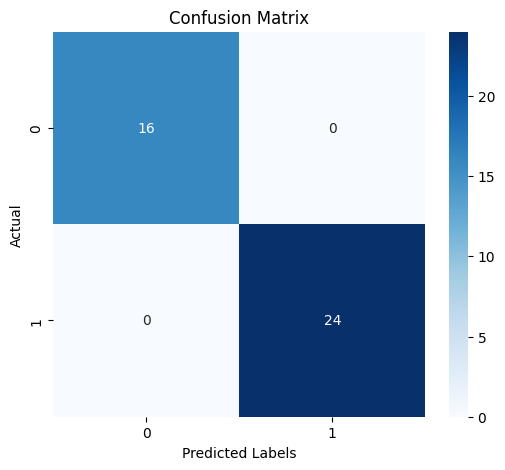

In [ ]:
#Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Predict New Review
def predict_sentiment(text):
  text=preprocess(text)
  vectorized_text = vectorize.transform([text]).toarray()
  prediction = model.predict(vectorized_text)
  return prediction[0]

print("\nNew Prediction:")
print(predict_sentiment("This movie was absolutely amazing"))


New Prediction:
positive


In [ ]:
print(predict_sentiment("The service was terrible and slow."))

negative


In [ ]:
print(predict_sentiment("The quality is outstanding and impressive."))

positive


In [ ]:
ps = PorterStemmer() # Re-initialize PorterStemmer to ensure 'ps' is the stemmer object
print(predict_sentiment("this movie was absolutely amazing"))

positive
